In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# =========================
# 1. Load data
# =========================
df = pd.read_csv("../data/processed/data.csv")

In [12]:
# =========================
# 2. Quick overview
# =========================
print("Dataset shape:", df.shape)
print("\nColumns and types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget summary:\n", df['taxa_abandono_em'].describe())


Dataset shape: (252, 10)

Columns and types:
 localizacao            object
rede                   object
atu_em                float64
had_em                float64
tdi_em                float64
taxa_aprovacao_em     float64
taxa_reprovacao_em    float64
dsu_em                float64
afd_em_grupo_1        float64
taxa_abandono_em      float64
dtype: object

Missing values:
 localizacao            0
rede                   0
atu_em                 0
had_em                36
tdi_em                 0
taxa_aprovacao_em      0
taxa_reprovacao_em     0
dsu_em                36
afd_em_grupo_1        72
taxa_abandono_em       0
dtype: int64

Target summary:
 count    252.000000
mean       6.103571
std        4.138521
min        0.200000
25%        2.400000
50%        6.100000
75%        9.100000
max       15.400000
Name: taxa_abandono_em, dtype: float64


In [13]:
# =========================
# 3. Correlation with target
# =========================
corr = df.corr(numeric_only=True)['taxa_abandono_em'].sort_values(ascending=False)
print("\nCorrelation with target:\n", corr)



Correlation with target:
 taxa_abandono_em      1.000000
tdi_em                0.864713
taxa_reprovacao_em    0.390559
atu_em                0.045312
dsu_em               -0.428224
afd_em_grupo_1       -0.574249
had_em               -0.581264
taxa_aprovacao_em    -0.853489
Name: taxa_abandono_em, dtype: float64


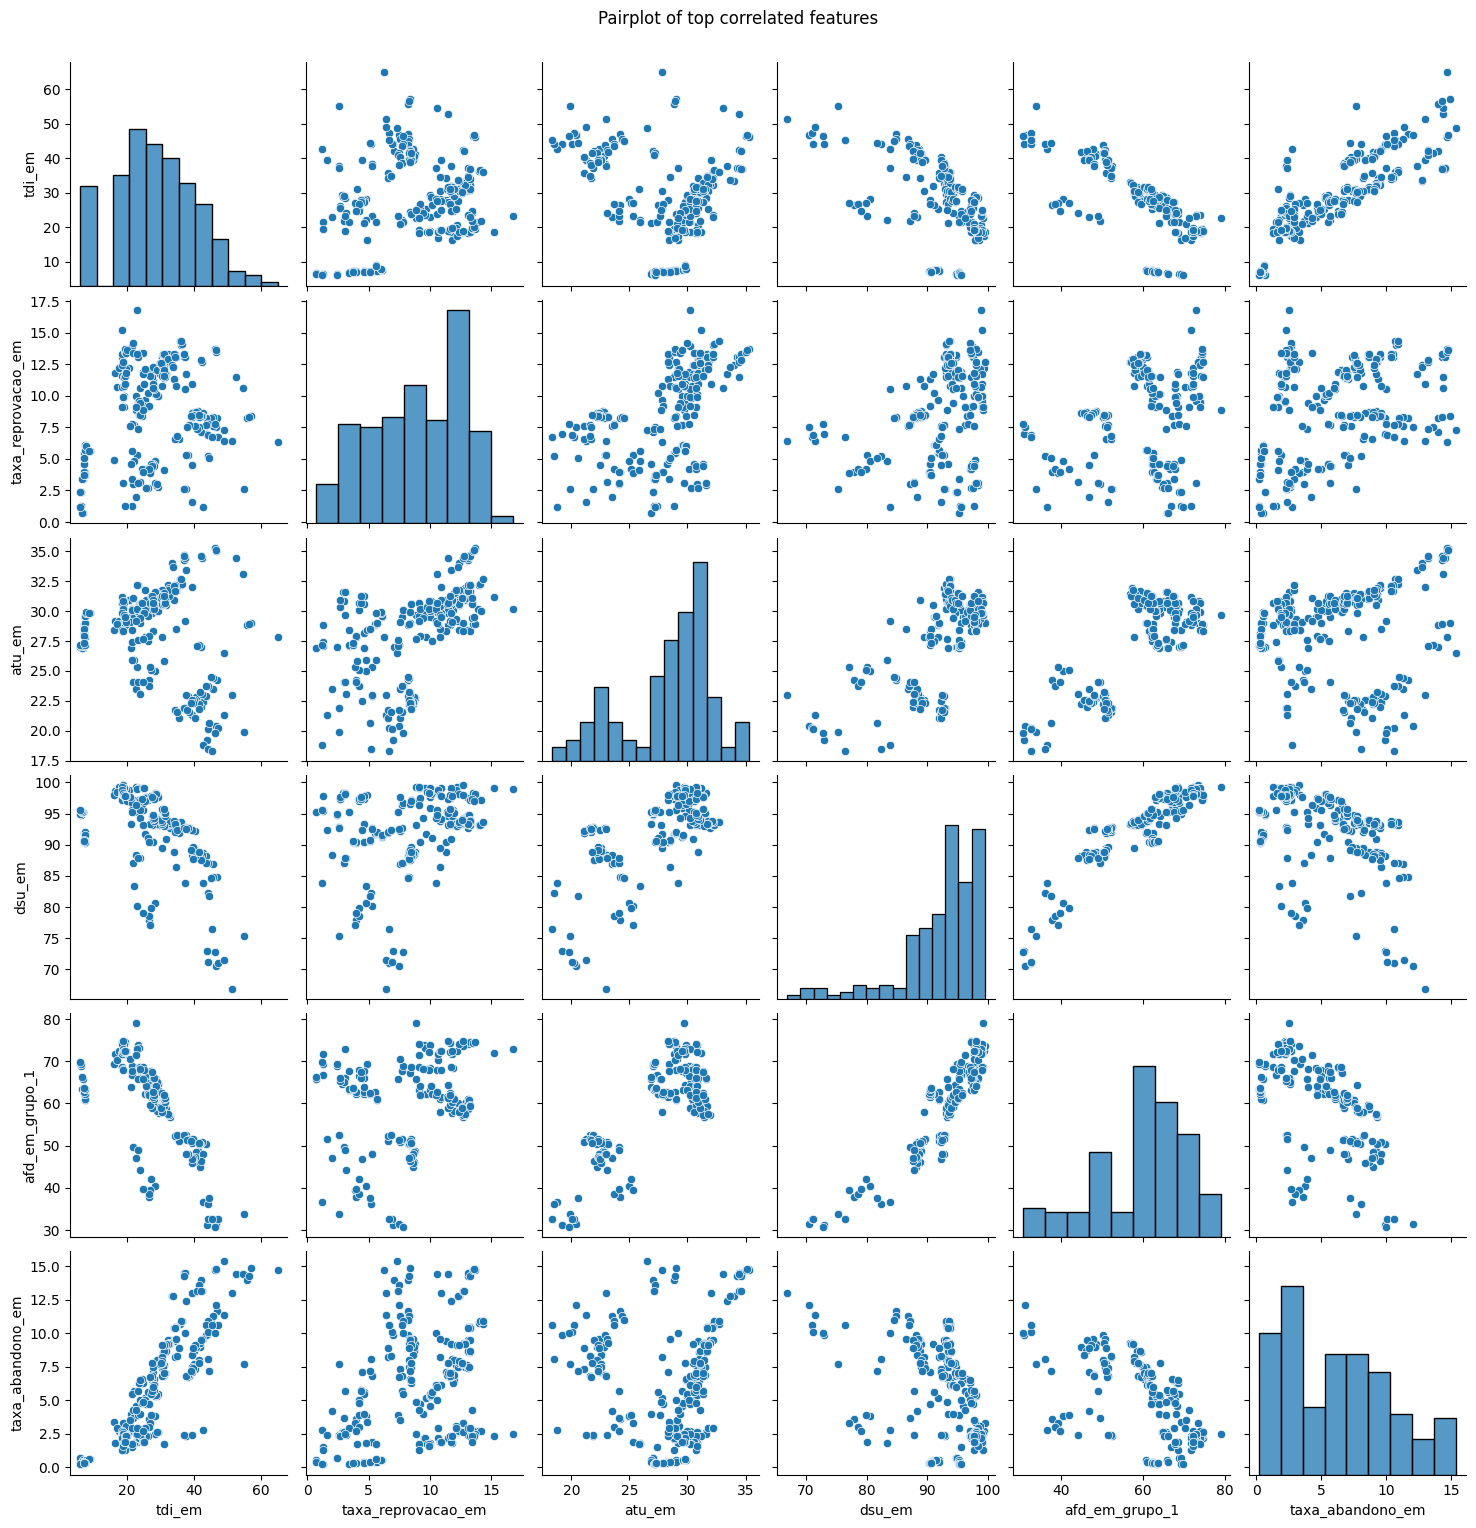

In [14]:
# =========================
# 4. Pairplot of top correlated features
# =========================
top_features = corr.index[1:6].tolist()  # top 5 features excluding target
sns.pairplot(df[top_features + ['taxa_abandono_em']])
plt.suptitle("Pairplot of top correlated features", y=1.02)
plt.show()


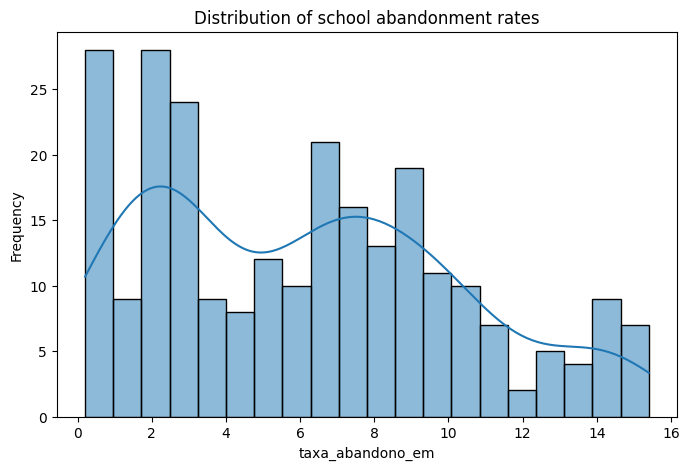

In [15]:
# =========================
# 5. Distribution of target
# =========================
plt.figure(figsize=(8,5))
sns.histplot(df['taxa_abandono_em'], bins=20, kde=True)
plt.title("Distribution of school abandonment rates")
plt.xlabel("taxa_abandono_em")
plt.ylabel("Frequency")
plt.show()


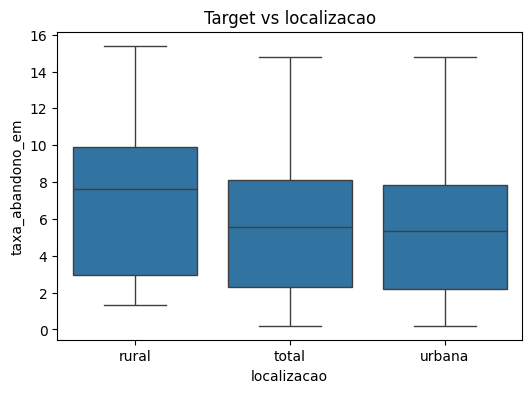

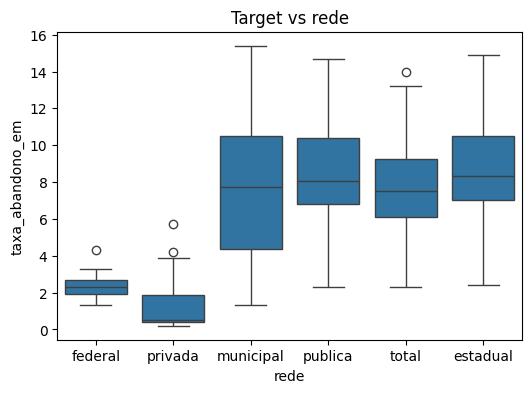

In [16]:
# =========================
# 6. Boxplots for categorical variables
# =========================
categorical_features = ['localizacao', 'rede']
for cat in categorical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=cat, y='taxa_abandono_em', data=df)
    plt.title(f"Target vs {cat}")
    plt.show()
